# Credit Card Fraud Detection
## Phase 3: Autoencoder Baseline

In this phase, we implement a PyTorch Autoencoder to learn the distribution of legitimate transactions. We will use mini-batch training with `DataLoader`, apply early stopping, and automatically detect/use GPU hardware (with mixed-precision training) if available.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, TensorDataset
import sys
import yaml
import time

# Add src to path
sys.path.append('../')
from src.preprocessing import split_data_anomaly_detection, preprocess_features, load_config
from src.autoencoder import Autoencoder, get_device, train_autoencoder, compute_reconstruction_error

# Load config
config = load_config('../configs/config.yaml')


### 1. Data Preparation
Load and preprocess the data exactly as in Phase 2.

In [2]:
# Load data
df = pd.read_csv('../' + config['data']['subset_path'])

# Split data
train_df, val_df, test_df = split_data_anomaly_detection(
    df, 
    val_size=config['data']['val_size'], 
    test_size=config['data']['test_size'], 
    random_state=config['random_seed']
)

# Preprocess features
(X_train, y_train), (X_val, y_val), (X_test, y_test), (scaler_time, scaler_amount) = preprocess_features(train_df, val_df, test_df)

print(f"X_train (Legitimate only): {X_train.shape}")
print(f"X_val (Mixed): {X_val.shape} (Fraud: {y_val.sum()})")


X_train (Legitimate only): (18000, 30)
X_val (Mixed): (6246, 30) (Fraud: 246)


### 2. Mini-batch DataLoaders
We create PyTorch `DataLoader` objects. Note that the Autoencoder is trained strictly on `X_train` without labels (unsupervised/self-supervised on normal data).

In [3]:
batch_size = config['training']['batch_size']

train_dataset = TensorDataset(torch.FloatTensor(X_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batches per epoch: {len(train_loader)}")


Batches per epoch: 71


### 3. Hardware & Model Setup
We automatically detect CUDA. If present, it will be used with Automatic Mixed Precision (AMP).

In [4]:
device = get_device()

input_dim = X_train.shape[1]
latent_dim = config['model']['latent_dim']
dropout = config['model']['dropout']

model = Autoencoder(input_dim=input_dim, latent_dim=latent_dim, dropout=dropout)
print(model)


Using CPU
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=22, bias=True)
    (1): BatchNorm1d(22, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=22, out_features=15, bias=True)
    (5): BatchNorm1d(15, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=15, out_features=14, bias=True)
    (9): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=14, out_features=15, bias=True)
    (1): BatchNorm1d(15, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=15, out_features=22, bias=True)
    (5): BatchNorm1d(22, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=

### 4. Training
Train the model, monitoring reconstruction loss (MSE).

In [5]:
start_time = time.time()

model, train_losses, val_losses = train_autoencoder(model, train_loader, val_loader, config, device)

end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds.")


Epoch 1/50 - Train Loss: 1.395246 - Val Loss: 2.106075


Epoch 2/50 - Train Loss: 1.150764 - Val Loss: 1.966861


Epoch 3/50 - Train Loss: 1.023853 - Val Loss: 1.834925


Epoch 4/50 - Train Loss: 0.981386 - Val Loss: 1.787144


Epoch 5/50 - Train Loss: 0.937440 - Val Loss: 1.765019


...

Epoch 23/50 - Train Loss: 0.784688 - Val Loss: 1.581287


Epoch 24/50 - Train Loss: 0.771190 - Val Loss: 1.604473


Epoch 25/50 - Train Loss: 0.774423 - Val Loss: 1.573415


Epoch 26/50 - Train Loss: 0.770255 - Val Loss: 1.565848


Epoch 27/50 - Train Loss: 0.757630 - Val Loss: 1.592337
Early stopping triggered.
Training completed in 51.69 seconds.


### 5. Training History
Visualizing the loss curves to check for convergence and overfitting.

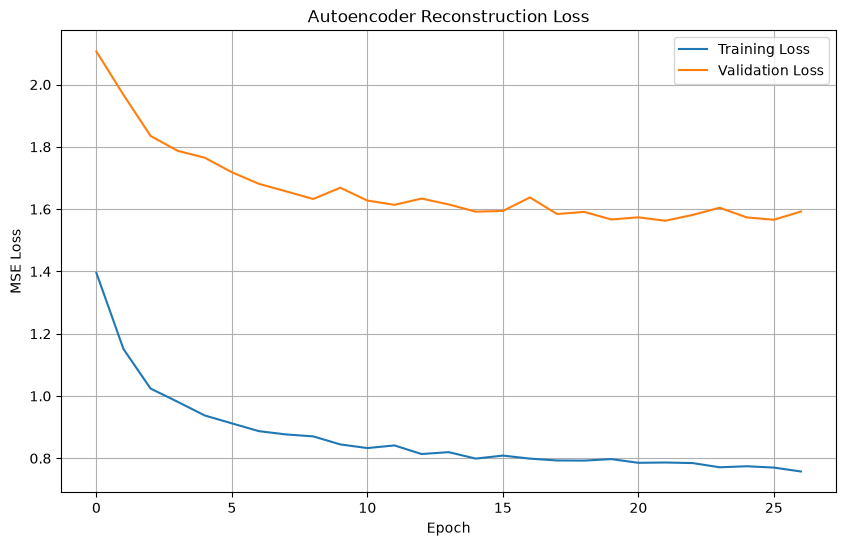

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Autoencoder Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


### 6. Reconstruction Error (Validation Set)
Calculate the reconstruction error for the validation set and compare distributions for legitimate vs fraudulent transactions.

Normal Val Error: Mean = 0.6846, Max = 58.4024
Fraud Val Error:  Mean = 23.7334, Min = 0.2484


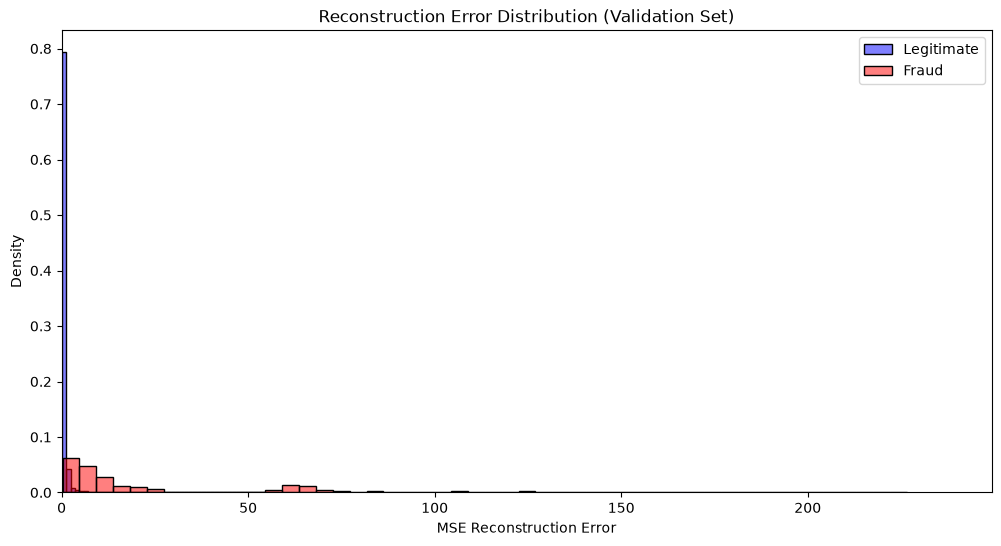

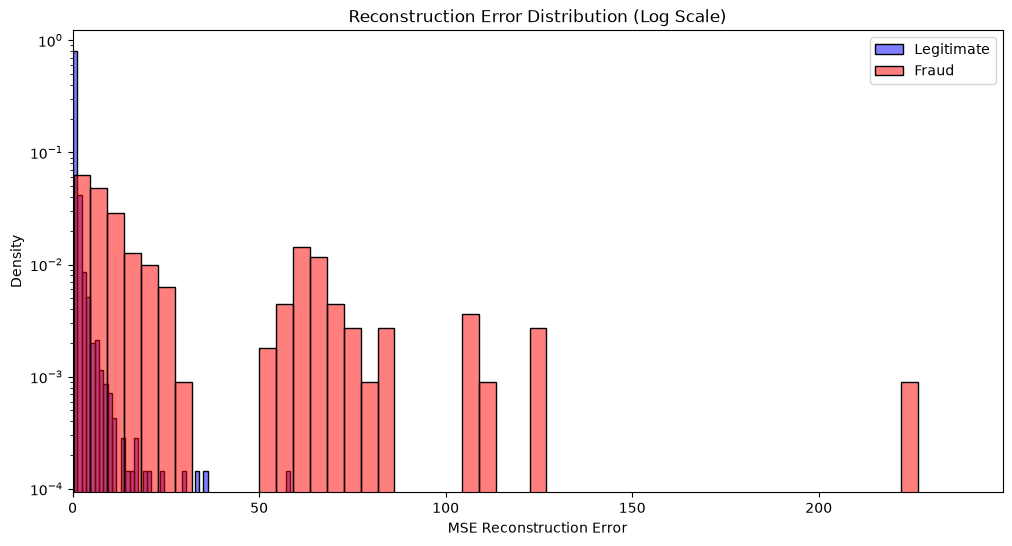

In [7]:
# Compute errors
val_errors = compute_reconstruction_error(model, val_loader, device)

# Separate by class
normal_errors = val_errors[y_val == 0]
fraud_errors = val_errors[y_val == 1]

print(f"Normal Val Error: Mean = {normal_errors.mean():.4f}, Max = {normal_errors.max():.4f}")
print(f"Fraud Val Error:  Mean = {fraud_errors.mean():.4f}, Min = {fraud_errors.min():.4f}")

# Plot distributions
plt.figure(figsize=(12, 6))
sns.histplot(normal_errors, bins=50, color='blue', alpha=0.5, label='Legitimate', stat='density')
sns.histplot(fraud_errors, bins=50, color='red', alpha=0.5, label='Fraud', stat='density')
plt.title('Reconstruction Error Distribution (Validation Set)')
plt.xlabel('MSE Reconstruction Error')
plt.ylabel('Density')
plt.xlim(0, max(fraud_errors.max(), normal_errors.max()) * 1.1)
plt.legend()
plt.show()

# Log scale plot for better visibility if skewed
plt.figure(figsize=(12, 6))
sns.histplot(normal_errors, bins=50, color='blue', alpha=0.5, label='Legitimate', stat='density')
sns.histplot(fraud_errors, bins=50, color='red', alpha=0.5, label='Fraud', stat='density')
plt.title('Reconstruction Error Distribution (Log Scale)')
plt.xlabel('MSE Reconstruction Error')
plt.ylabel('Density')
plt.yscale('log')
plt.xlim(0, max(fraud_errors.max(), normal_errors.max()) * 1.1)
plt.legend()
plt.show()


### 7. Save Baseline Model

In [8]:
torch.save(model.state_dict(), '../models/autoencoder_baseline.pth')
print("Model saved to models/autoencoder_baseline.pth")


Model saved to models/autoencoder_baseline.pth
